# **Lab : Analyse des séries temporelles dans R**

Il s’agit ici d’un tutoriel qui présente plusieurs méthodes d’analyse et de prévision de séries temporelles avec R. Il inclut des approches classiques (SARIMA, régression dynamique) ainsi que des méthodes plus récentes (Prophet), avec une comparaison des résultats obtenus.

Le but est de proposer un tutoriel simple, reproductible et pédagogique pour aider à comprendre et à utiliser les principaux modèles de prévision.

In [ ]:
install.packages("fma")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
install.packages('forecast')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’




# **Partie 1 : Modèle SARIMA**

## **Question 1 : Identification manuelle d’un modèle SARIMA pour la série fancy**

### **Chargement des données et visualisation de base**

In [ ]:
library(fma)
library(ggplot2)
library(forecast)


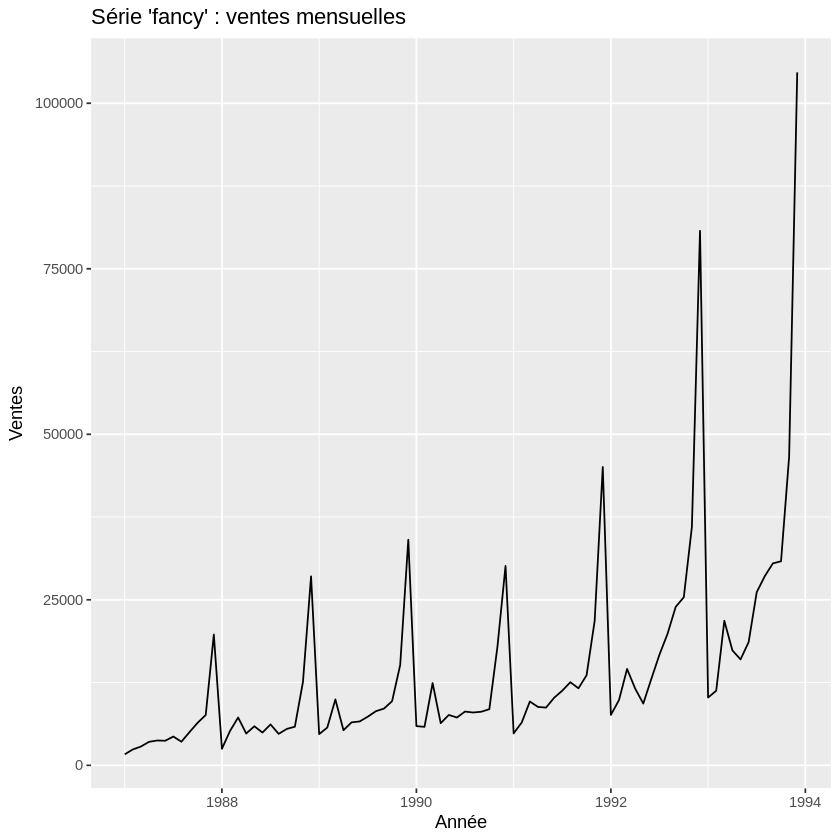

In [ ]:
data("fancy")

autoplot(fancy) +
  ggtitle("Série 'fancy' : ventes mensuelles") +
  xlab("Année") + ylab("Ventes")


**Analyse visuelle de la série**

- **Variance :** La moyenne des ventes n’est pas la même partout : elle augmente clairement vers la fin. Les fluctuations deviennent de plus en plus grandes.  
  - La variance n’est donc **pas constante**, elle **n’est pas stable**.  
  - On devra la **stabiliser** avec une **transformation Box-Cox**.

- **Tendance :** Comme la variance augmente, n'est pas stable, et on voit aussi que les ventes **croissent d’année en année**, on peut dire que :  
  - Il y a une **tendance croissante**.  
  - La série **n’est pas stationnaire** : on devra appliquer une **différenciation (non saisonnière)**.

- **Saison :** On remarque des **pics réguliers chaque année**, toujours à peu près aux mêmes mois.  
  - Il y a une **saisonnalité annuelle** bien marquée.  
  - On devra appliquer une **différenciation (saisonnière)** (lag = 12).

- **Conclusion :** Pour rendre la série modélisable, on devra :  
  - stabiliser la variance avec **Box-Cox**,  
  - supprimer la tendance avec une **différence non saisonnière**,  
  - supprimer la saisonnalité avec une **différence saisonnière**.

### **Transformation Box-Cox (stabilisation de la variance)**

In [ ]:
lambda <- BoxCox.lambda(fancy)
lambda

[1] 0.002127317

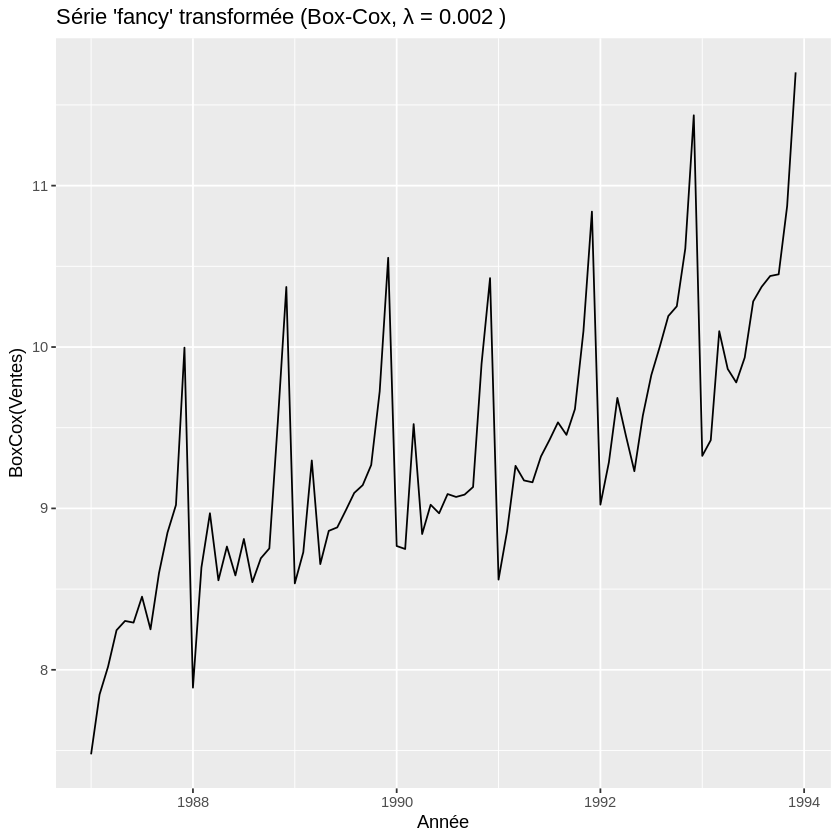

In [ ]:
fancy_bc <- BoxCox(fancy, lambda)

autoplot(fancy_bc) +
  ggtitle(paste("Série 'fancy' transformée (Box-Cox, λ =",
                round(lambda, 3), ")")) +
  xlab("Année") + ylab("BoxCox(Ventes)")

La transformation Box‑Cox appliquée à la série `fancy` (λ ≈ 0.002) a permis de **réduire les variations trop fortes**, mais la variance **n’est pas parfaitement stabilisée**. On voit encore que les fluctuations sont un peu plus grandes vers la fin de la série. Cela peut venir du fait que la série a une structure où les variations augmentent naturellement avec le niveau, et la transformation ne corrige pas tout à 100%.

- Malgré cela, la série est **suffisamment stabilisée** pour continuer l’analyse.  
- On peut donc passer aux étapes de différenciation pour rendre la série stationnaire en tendance et en saisonnalité.

### **Différenciation saisonnière**

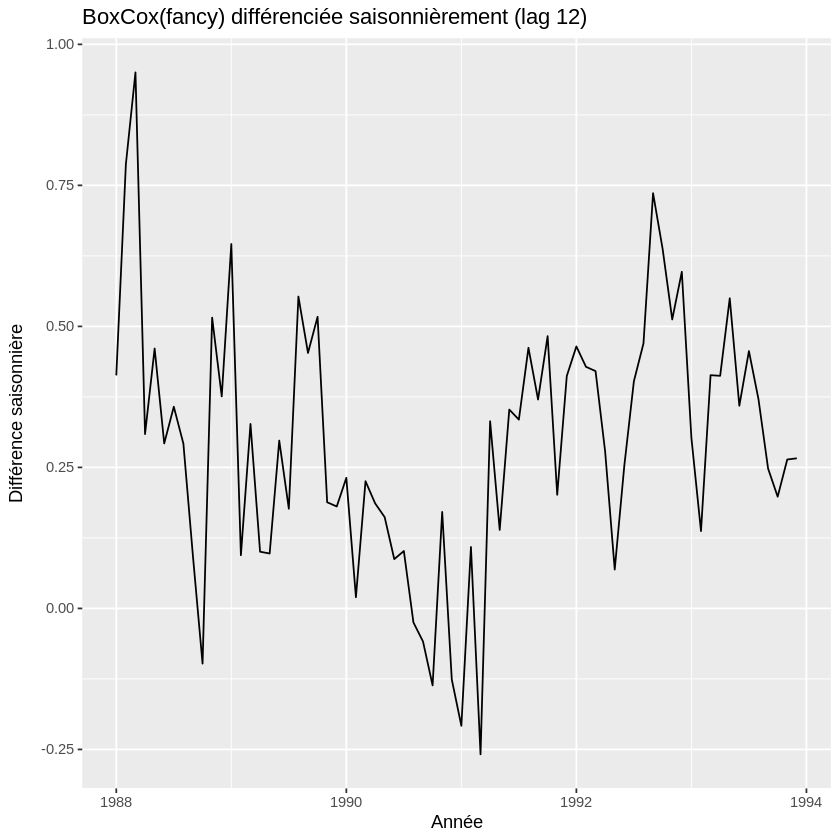

In [ ]:
fancy_bc_diffS <- diff(fancy_bc, lag = 12, differences = 1)

autoplot(fancy_bc_diffS) +
  ggtitle("BoxCox(fancy) différenciée saisonnièrement (lag 12)") +
  xlab("Année") + ylab("Différence saisonnière")

Après avoir appliqué une **différenciation saisonnière** (lag = 12) sur la série transformée, on observe que :

- La saisonnalité est fortement atténuée : les pics réguliers ont disparu, les fluctuations sont plus irrégulières,
- Mais la **moyenne n’est pas constante** tout au long de la série, ce qui suggère une **tendance résiduelle**.

- Cela signifie que la série **n’est pas encore stationnaire en tendance**.  
  - On doit donc appliquer une **différenciation non saisonnière** (lag = 1) pour éliminer cette tendance.


### **Différenciation non saisonnière**

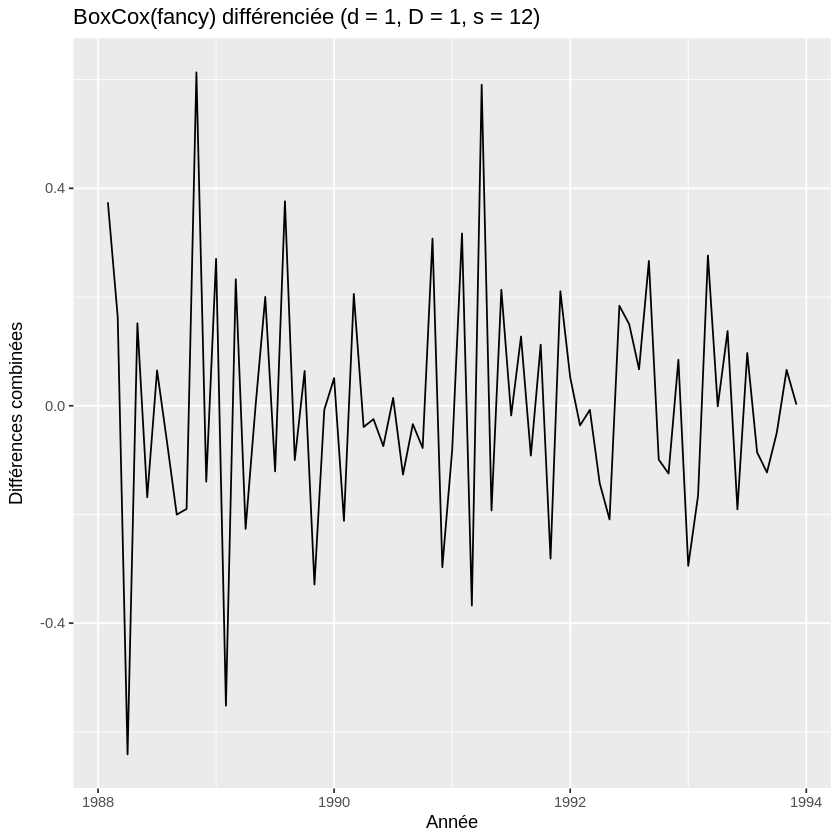

In [ ]:
fancy_bc_diffSD <- diff(fancy_bc_diffS, differences = 1)

autoplot(fancy_bc_diffSD) +
  ggtitle("BoxCox(fancy) différenciée (d = 1, D = 1, s = 12)") +
  xlab("Année") + ylab("Différences combinées")


- La série semble maintenant **sans tendance apparente**, oscillant autour d’une moyenne constante.  
- La variance est stable, plus de saisonnalité visible.  
- La série est donc stationnaire.

On retient donc une structure de différenciation :  
- **d = 1** (différence non saisonnière)  
- **D = 1** (différence saisonnière, période 12)  

Le modèle global sera donc de type :  **$\text{SARIMA}(p,1,q)(P,1,Q)_{12}$**

### **Identification des paramètres via `tsdisplay` (ACF/PACF)**

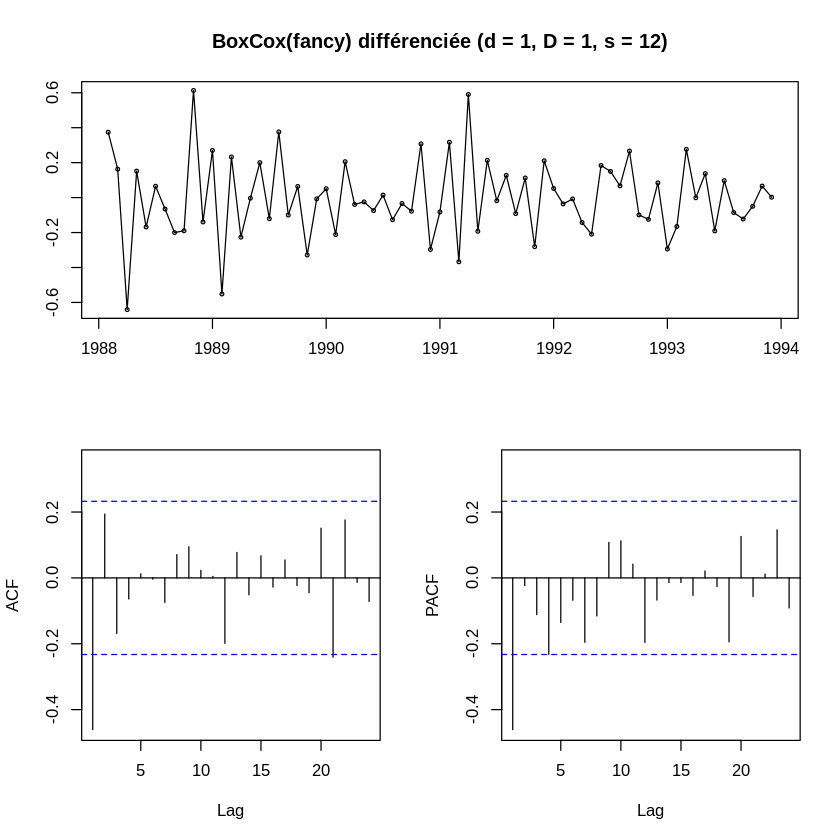

In [ ]:
tsdisplay(fancy_bc_diffSD,
          main = "BoxCox(fancy) différenciée (d = 1, D = 1, s = 12)")

Après avoir appliqué une double différenciation (d = 1, D = 1), l’analyse des fonctions ACF et PACF montre une **autocorrélation négative à lag 1**, ce qui suggère que la série a été **trop différenciée**.  
- On décide donc de **revenir à une seule différenciation saisonnière** (D = 1, d = 0), ce qui donne une série plus stable et mieux centrée.  
- Le modèle SARIMA envisagé devient : **$\text{SARIMA}(p,0,q)(P,1,Q)_{12}$**

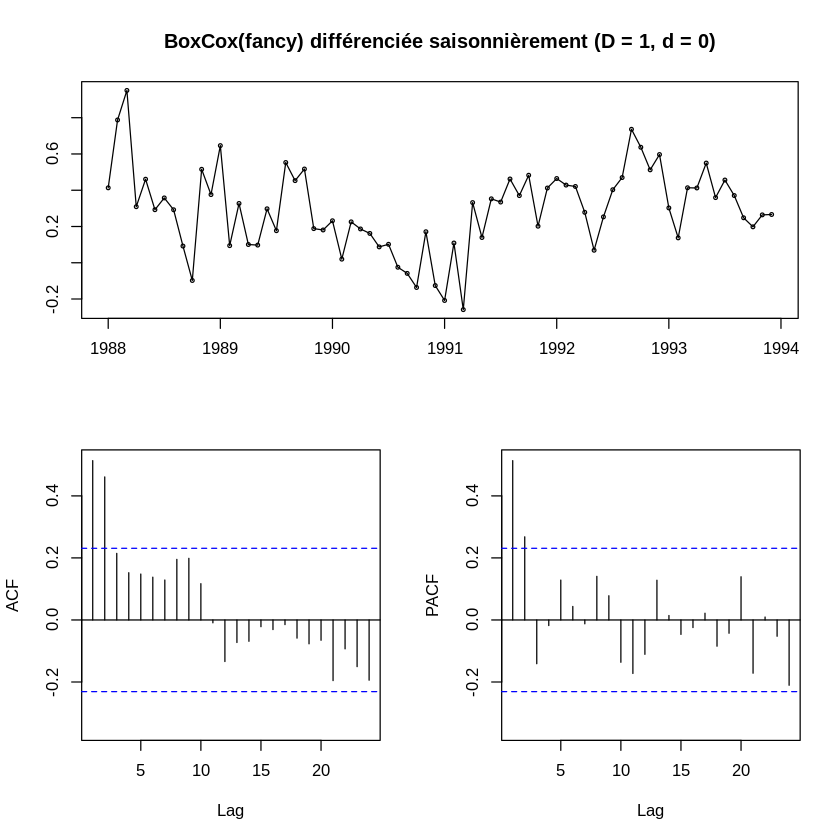

In [ ]:
tsdisplay(fancy_bc_diffS,
          main = "BoxCox(fancy) différenciée saisonnièrement (D = 1, d = 0)")


- **Partie saisonnière :**
  - Les **lags multiples de 12** (12, 24, …) sont **dans la bande non significative** en ACF et PACF.
  - Ça veut dire qu’**après la différenciation saisonnière (D = 1)**, il ne reste **pas de structure saisonnière résiduelle forte** à modéliser.
  - On peut donc prendre :
    - **P = 0** et **Q = 0**.
  - La **saison n’est pas "oubliée"** : c’est la **différenciation saisonnière (D = 1, période 12)** qui la gère déjà. Le modèle "sait" qu’il y a une saisonnalité parce qu’on lui a donné cette information via \(D = 1\) et \(s = 12\), même si on met \(P = Q = 0\).

- **Partie non saisonnière :**
  - L **ACF et PACF décroissent toutes les deux**, on est donc en présence d’une structure qui peut être approchée par :
    - soit un **AR(p)**, soit un **MA(q)**, on a donc :
      - **AR(2)** :  **SARIMA(2,0,0)(0,1,0)\_12**
      - **MA(2)** : **SARIMA(0,0,2)(0,1,0)\_12**  
      

**Conclusion**
- Comme modèles candidats on a : **$\text{SARIMA}(2,0,0)(0,1,0)_{12}$** et **$\text{SARIMA}(0,0,2)(0,1,0)_{12}$**

## **Question 2 : Competition**

Il s'agit ici de comparer les modèles manuels avec auto.arima().

In [ ]:
# Modèles manuels
fit_ar2 <- Arima(fancy_bc,
                 order    = c(2, 0, 0),
                 seasonal = c(0, 1, 0))

fit_ma2 <- Arima(fancy_bc,
                 order    = c(0, 0, 2),
                 seasonal = c(0, 1, 0))


In [ ]:
# Modèle automatique
fit_auto <- auto.arima(fancy_bc,
                       seasonal = TRUE)

### **Comparaison des AIC et métriques**

In [ ]:
cat('-------------SARIMA ar2----------------------')
summary(fit_ar2)
cat('-------------SARIMA ma2----------------------')
summary(fit_ma2)
cat('-------------auto arima----------------------')
summary(fit_auto)

-------------SARIMA ar2----------------------

Series: fancy_bc 
ARIMA(2,0,0)(0,1,0)[12] 

Coefficients:
         ar1    ar2
      0.4833  0.416
s.e.  0.1067  0.110

sigma^2 = 0.03899:  log likelihood = 14.9
AIC=-23.79   AICc=-23.44   BIC=-16.96

Training set error measures:
                     ME      RMSE      MAE      MPE     MAPE     MASE
Training set 0.02620496 0.1802499 0.134437 0.268054 1.446993 0.420572
                   ACF1
Training set 0.00737277

-------------SARIMA ma2----------------------

Series: fancy_bc 
ARIMA(0,0,2)(0,1,0)[12] 

Coefficients:
         ma1     ma2
      0.5355  0.6178
s.e.  0.1435  0.0878

sigma^2 = 0.05668:  log likelihood = 1.65
AIC=2.7   AICc=3.05   BIC=9.53

Training set error measures:
                    ME      RMSE       MAE      MPE     MAPE      MASE
Training set 0.1189569 0.2173331 0.1693294 1.248736 1.803361 0.5297292
                    ACF1
Training set -0.05771734

-------------auto arima----------------------

Series: fancy_bc 
ARIMA(2,0,0)(0,1,1)[12] with drift 

Coefficients:
         ar1     ar2     sma1   drift
      0.3476  0.3510  -0.5196  0.0243
s.e.  0.1093  0.1115   0.1700  0.0032

sigma^2 = 0.03071:  log likelihood = 23.15
AIC=-36.3   AICc=-35.39   BIC=-24.91

Training set error measures:
                       ME      RMSE      MAE         MPE     MAPE     MASE
Training set 0.0005573197 0.1576685 0.117769 -0.01409905 1.268801 0.368428
                   ACF1
Training set 0.03816941

In [ ]:
AIC(fit_ar2, fit_ma2, fit_auto)

,df,AIC
,<dbl>,<dbl>
fit_ar2,3,-23.79373
fit_ma2,3,2.69726
fit_auto,5,-36.29548


Nous comparons ici les trois modèles estimés sur la série transformée par BoxCox `fancy_bc` :

- **Modèle manuel 1 :** $SARIMA(2,0,0)(0,1,0)_{12}$  
- **Modèle manuel 2 :** $SARIMA(0,0,2)(0,1,0)_{12}$  
- **Modèle automatique :** $SARIMA(2,0,0)(0,1,1){12}$ avec drift


#### - **Interprétation en fonction du critères d’information (AIC, AICc, BIC)**

- Le modèle **MA(2)** est clairement le moins bon (AIC très élevé).  
- Le modèle **AR(2)** est correct mais reste moins performant.  
- Le modèle **auto.arima** présente les **meilleurs AIC, AICc et BIC**.

**Conclusion 1** : Sur les critères d’information, le modèle automatique est le meilleur.



#### - **Interprétation en fonction des mesures d’erreur (RMSE, MAE, MAPE)**

- Le modèle **MA(2)** est encore le moins bon.  
- Le modèle **AR(2)** est raisonnable.  
- Le modèle **auto.arima** a les **meilleures erreurs (RMSE, MAE, MAPE)**.

**Conclusion 2** : Sur les erreurs d’apprentissage, le modèle automatique est encore le meilleur.


### **Conclusion globale**

- Sur la base des critères AIC/AICc/BIC et des mesures d’erreur (RMSE, MAE, MAPE), le modèle **$SARIMA(2,0,0)(0,1,1)_{12}$** proposé par `auto.arima()` est le plus performant mais il est plus complexe car il a plus de paramètres.  
- Le modèle manuel **AR(2)** reste acceptable et est un bon compromis entre performance et complexité.
- Tandis que le modèle **MA(2)** est nettement moins bon.

### **Analyse des résidus (diagnostics) pour validation**

#### **Modèle manuel 1 : $SARIMA(2,0,0)(0,1,0)_{12}$**

-----------------résidus ar2-----------
	Ljung-Box test

data:  Residuals from ARIMA(2,0,0)(0,1,0)[12]
Q* = 21.404, df = 15, p-value = 0.1244

Model df: 2.   Total lags used: 17



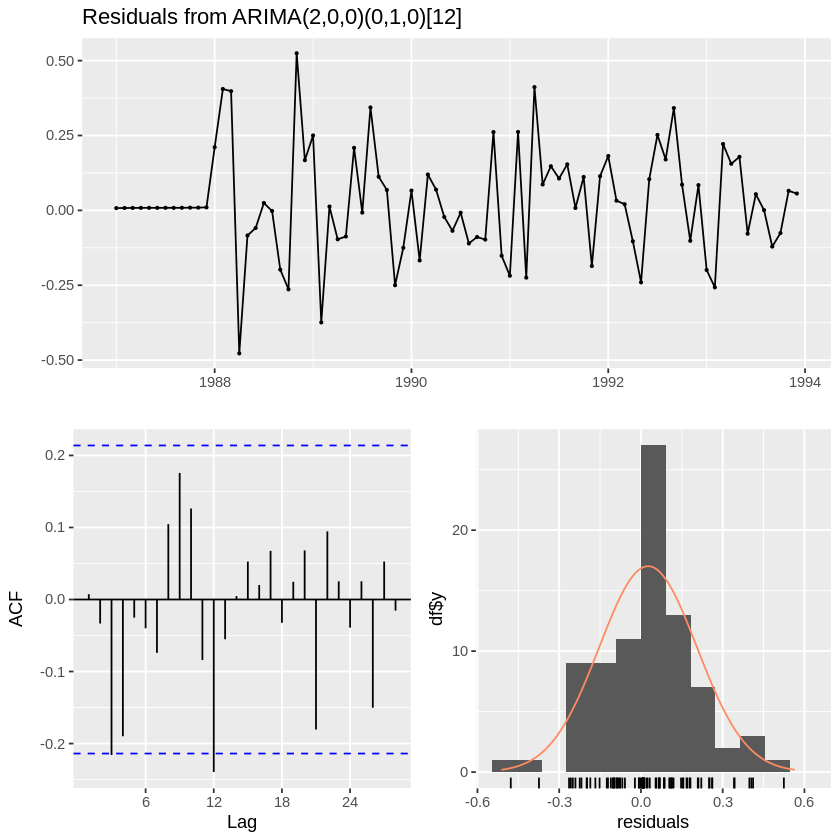

In [ ]:
cat('-----------------résidus ar2-----------')
checkresiduals(fit_ar2)

On observe :
- **Moyenne nulle** : les résidus sont centrés autour de zéro.  
- **Variance stable** : pas de changement d’amplitude visible.  
- **Correlogramme ACF** : la **majorité des pics sont dans les bandes non significatives**, donc **pas d’autocorrélation résiduelle forte**.  
- **Test de Ljung-Box** : p-value = 0.1244 > 0.05 -> on **ne rejette pas** l’hypothèse de bruit blanc.

**Conclusion intermédiaire :** les résidus sont compatibles avec un bruit blanc -> modèle **statistiquement valide**

#### **Modèle manuel 2 : $SARIMA(0,0,2)(0,1,0)_{12}$**

-----------------résidus ma2-----------
	Ljung-Box test

data:  Residuals from ARIMA(0,0,2)(0,1,0)[12]
Q* = 17.591, df = 15, p-value = 0.2848

Model df: 2.   Total lags used: 17



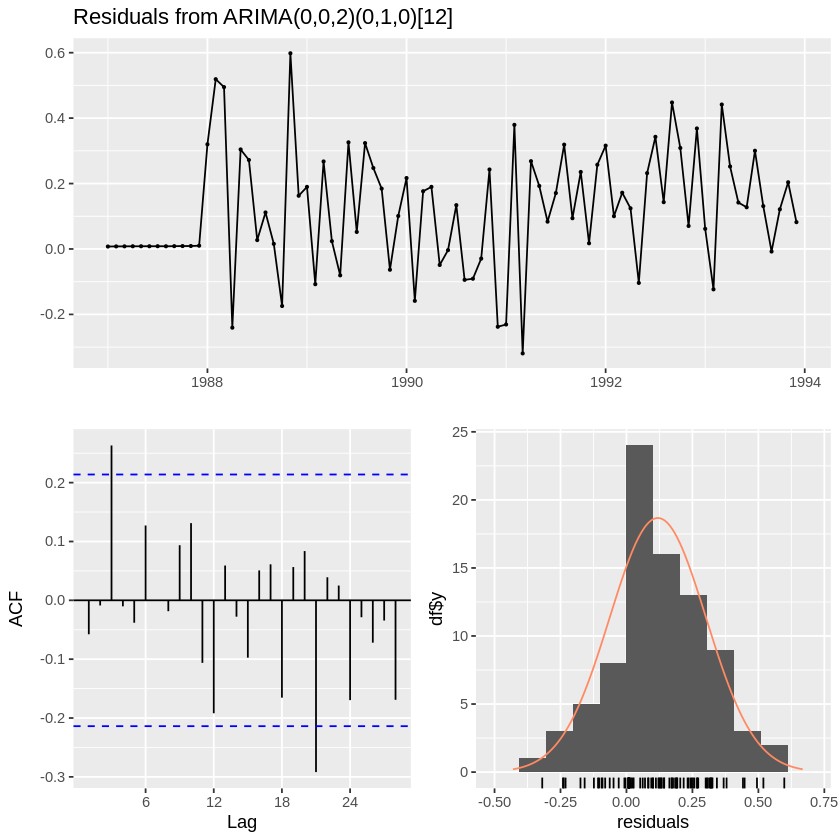

In [ ]:
cat('-----------------résidus ma2-----------')
checkresiduals(fit_ma2)

On observe que :

- **Moyenne proche de zéro**, mais un peu plus dispersée.  
- **Variance stable**, bien que les fluctuations soient un peu plus larges.  
- **Correlogramme ACF** : la **majorité des barres sont dans les bandes**, donc **pas d’autocorrélation significative**.  
- **Test de Ljung-Box** : p-value = 0.2848 > 0.05 -> on **ne rejette pas** l’hypothèse de bruit blanc.

**Conclusion intermédiaire :** les résidus sont acceptables -> modèle **valide**, mais moins convaincant

#### **Modèle automatique : $SARIMA(2,0,0)(0,1,1)_{12}$ avec drift**

-----------------résidus auto-----------
	Ljung-Box test

data:  Residuals from ARIMA(2,0,0)(0,1,1)[12] with drift
Q* = 11.874, df = 14, p-value = 0.6164

Model df: 3.   Total lags used: 17



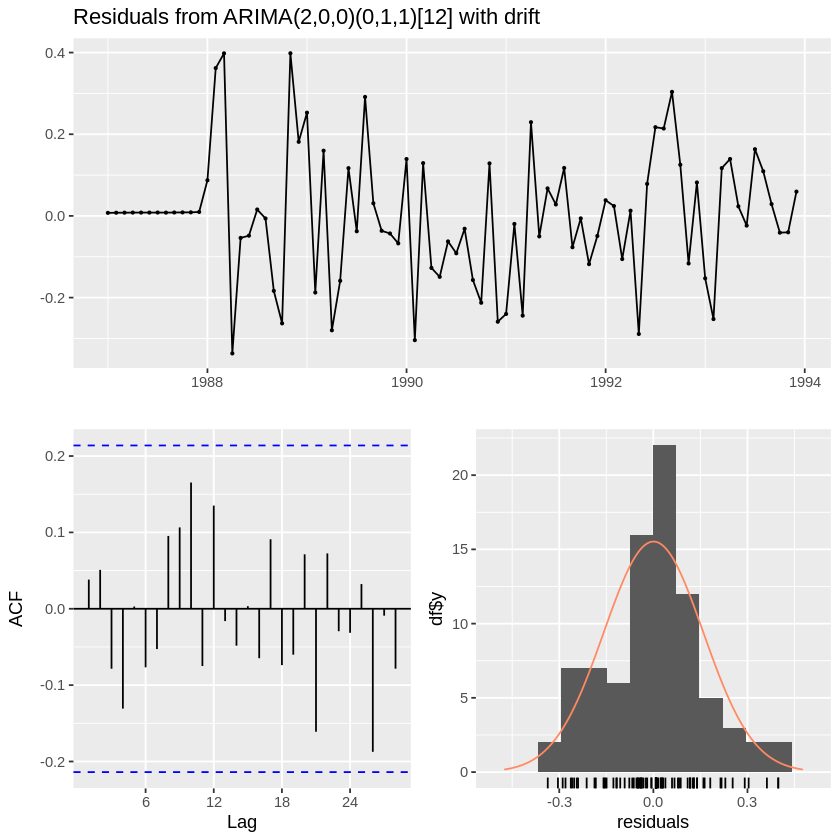

In [ ]:
cat('-----------------résidus auto-----------')
checkresiduals(fit_auto)

On observe que :

- **Moyenne nulle** : les résidus sont parfaitement centrés.  
- **Variance constante** : fluctuations homogènes.  
- **Correlogramme ACF** : **tous les pics sont dans les bandes non significatives** -> **aucune autocorrélation résiduelle**.  
- **Test de Ljung-Box** : p-value = 0.6164 -> très largement non significatif.

**Conclusion intermédiaire :** les résidus sont **parfaitement compatibles avec un bruit blanc** -> modèle **très bien ajusté**


### **Conclusion globale**

Sur l’ensemble des critères, le modèle **auto.arima** ressort comme le meilleur.  
- **Côté bruit blanc**, c’est celui qui présente les résidus les plus propres : parfaitement centrés, variance stable et aucune autocorrélation résiduelle.  
- **Côté métriques**, il obtient les meilleurs AIC, AICc, BIC et les plus faibles erreurs (RMSE, MAE, MAPE).  
- Cela se fait **au détriment d’une complexité plus élevée** (plus de paramètres), mais ce surcoût est **compensé par un gain clair en performance**.

Le modèle manuel **AR(2)** reste une **bonne alternative**, plus simple et raisonnablement performant, mais **le compromis global penche en faveur du modèle automatique**.

# **Partie 2 : Régression Dynamique**

Ici on veut modéliser l'impact de la publicité sur les devis en utilisant une régression avec erreurs ARIMA.

## **Chargement et analyse Descriptive**

In [ ]:
data(insurance)

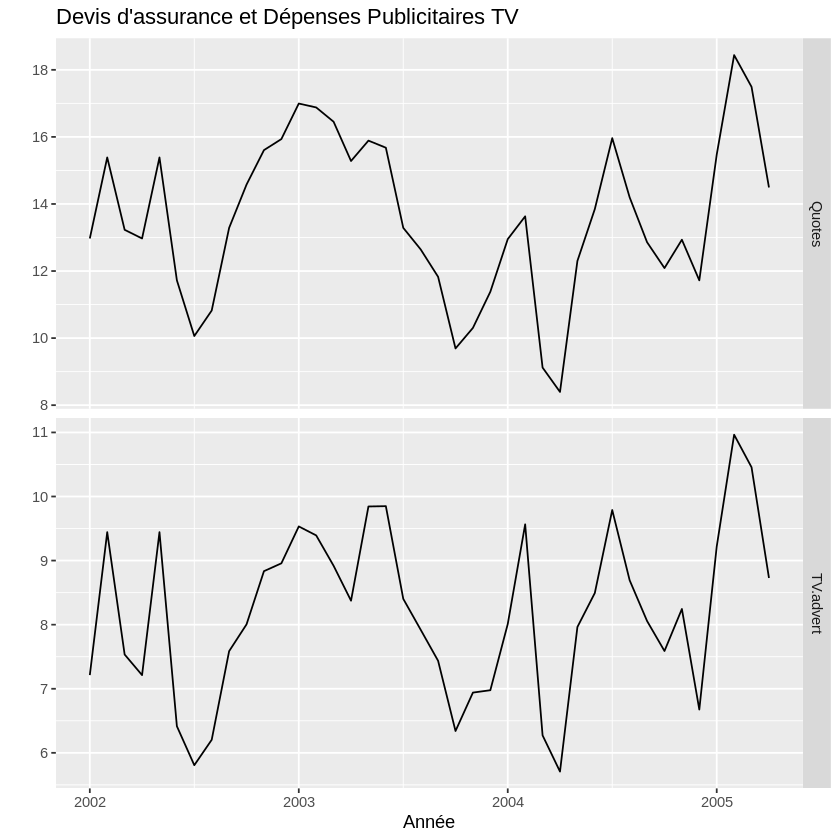

In [ ]:
autoplot(insurance, facets = TRUE) +
  ggtitle("Devis d'assurance et Dépenses Publicitaires TV") +
  ylab("") +
  xlab("Année")

## **Q1. Spurious Regression**

Nous commençons par ajuster une régression linéaire simple  $Quotes_t = \beta_0 + \beta_1 TV.advert_t + e_t$, afin de vérifier si elle permet de modéliser correctement la série.

Pour que ce modèle soit acceptable, ses résidus \(e_t\) doivent se comporter comme un bruit blanc, c’est‑à‑dire être indépendants et centrés autour de zéro.

In [ ]:
# Entrainement du modèle de régression
lm_model <- lm(Quotes ~ TV.advert, data = as.data.frame(insurance))

In [ ]:
summary(lm_model)


Call:
lm(formula = Quotes ~ TV.advert, data = as.data.frame(insurance))

Residuals:
    Min      1Q  Median      3Q     Max 
-2.3274 -0.5426 -0.2379  0.7543  1.5884 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -0.2402     0.9008  -0.267    0.791    
TV.advert     1.6934     0.1088  15.562   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8952 on 38 degrees of freedom
Multiple R-squared:  0.8644,	Adjusted R-squared:  0.8608 
F-statistic: 242.2 on 1 and 38 DF,  p-value: < 2.2e-16


Du summary on peut voir que, :

- Le coefficient de détermination **R²** est élevé, ce qui peut donner l’impression que le modèle fonctionne très bien.  
- Cependant, dans les séries temporelles, deux variables qui évoluent dans le même sens peuvent créer une fausse impression de lien.  
- De même, des coefficients très significatifs (p‑value faible) ne suffisent pas à garantir que le modèle est valide.

Pour vérifier réellement la qualité du modèle, il est donc nécessaire d’examiner les résidus.



### **Diagnostic des résidus**

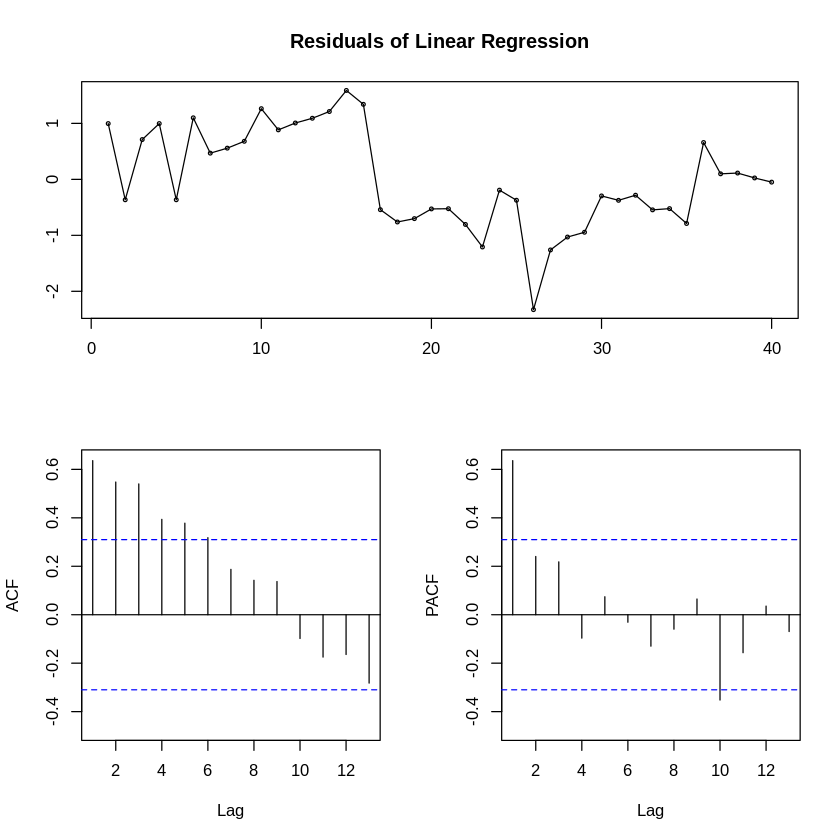

In [ ]:
# Plot residuals
tsdisplay(residuals(lm_model), main = "Residuals of Linear Regression")

In [ ]:
# Durbin-Watson test for autocorrelation
Box.test(residuals(lm_model), type = "Ljung-Box")


	Box-Ljung test

data:  residuals(lm_model)
X-squared = 17.426, df = 1, p-value = 2.987e-05


* **Diagnostic des résidus** :

  - **ACF des résidus (en bas à gauche)**  
    - Plusieurs barres dépassent les bandes bleues : il y a **autocorrélation significative**.  
    - Cela indique que les erreurs sont **corrélées dans le temps**, ce qui viole les hypothèses des moindres carrés ordinaires (MCO).

  - **PACF des résidus (en bas à droite)**  
    - On observe des pics nets aux premiers lags, ce qui suggère une **structure AR résiduelle non modélisée**.
    
  - Le test de Ljung-Box confirme une autocorrélation significative dans les résidus (valeur p < 0,05), démontrant pourquoi une simple régression linéaire est inappropriée ici.

Le graphe des résidus montre clairement que le modèle linéaire simple ne capture pas la dépendance temporelle présente dans la série. Les erreurs sont autocorrélées et structurées, ce qui invalide les hypothèses classiques de la régression. Il s’agit d’un cas typique de **régression fallacieuse** : la relation apparente entre les variables est amplifiée par des tendances communes non modélisées. Pour corriger cela, il faut intégrer explicitement la structure des erreurs, par exemple via une **régression dynamique avec erreurs ARIMA**.


## **Q2. Régression Dynamique (Modèle avec Erreurs ARIMA)**


In [ ]:
dyn_model <- auto.arima(insurance[,"Quotes"],
                        xreg = insurance[,"TV.advert"])

In [ ]:
summary(dyn_model)

Series: insurance[, "Quotes"] 
Regression with ARIMA(0,1,0) errors 

Coefficients:
        xreg
      1.3485
s.e.  0.0666

sigma^2 = 0.3301:  log likelihood = -33.22
AIC=70.44   AICc=70.77   BIC=73.77

Training set error measures:
                      ME      RMSE       MAE         MPE     MAPE      MASE
Training set -0.01299736 0.5599955 0.4354811 -0.09980506 3.271638 0.1268871
                  ACF1
Training set 0.1664547

Le modèle ajuste la série `Quotes` en fonction de la variable explicative `TV.advert`, tout en modélisant les erreurs comme un processus ARIMA(0,1,0), c’est‑à‑dire un **bruit intégré sans structure autorégressive ni moyenne mobile**. Cela permet de corriger les dépendances temporelles non capturées par une régression classique.

- Le coefficient associé à `TV.advert` est **1.3485**, avec un **écart-type de 0.0666**, ce qui indique une **relation forte et statistiquement significative** entre la publicité télévisée et les demandes de devis.

- Les erreurs d’ajustement sont faibles :  
  - **RMSE = 0.56**, **MAE = 0.435**, **MAPE ≈ 3.27 %**  
  - Le **MASE = 0.127 < 1** montre que le modèle est **nettement meilleur qu’un naïf saisonnier**.  

- Le **log-vraisemblance élevé** et les critères d’information (**AIC = 70.44**, **BIC = 73.77**) confirment une bonne qualité d’ajustement.


- L’**ACF1 = 0.166** reste légèrement élevé, ce qui suggère une **autocorrélation résiduelle modérée**.  
- Cela peut indiquer que le modèle ARIMA(0,1,0) ne capture pas entièrement la structure des erreurs, et qu’un modèle plus riche (ARIMA(p,d,q) avec \(p > 0\) ou \(q > 0\)) pourrait être testé.


**Conclusion :**

Le modèle dynamique avec erreurs ARIMA(0,1,0) permet de corriger les biais de la régression linéaire simple en tenant compte de la dépendance temporelle des erreurs. La relation entre `TV.advert` et `Quotes` est significative, et les performances d’ajustement sont solides (MAPE < 4 %, MASE < 0.2). Toutefois, la présence d’une autocorrélation résiduelle modérée invite à envisager une spécification plus riche des erreurs pour améliorer le modèle.

### **Vérification des residus de la regression dynamique : Validation du modèle**




	Ljung-Box test

data:  Residuals from Regression with ARIMA(0,1,0) errors
Q* = 9.1602, df = 8, p-value = 0.329

Model df: 0.   Total lags used: 8



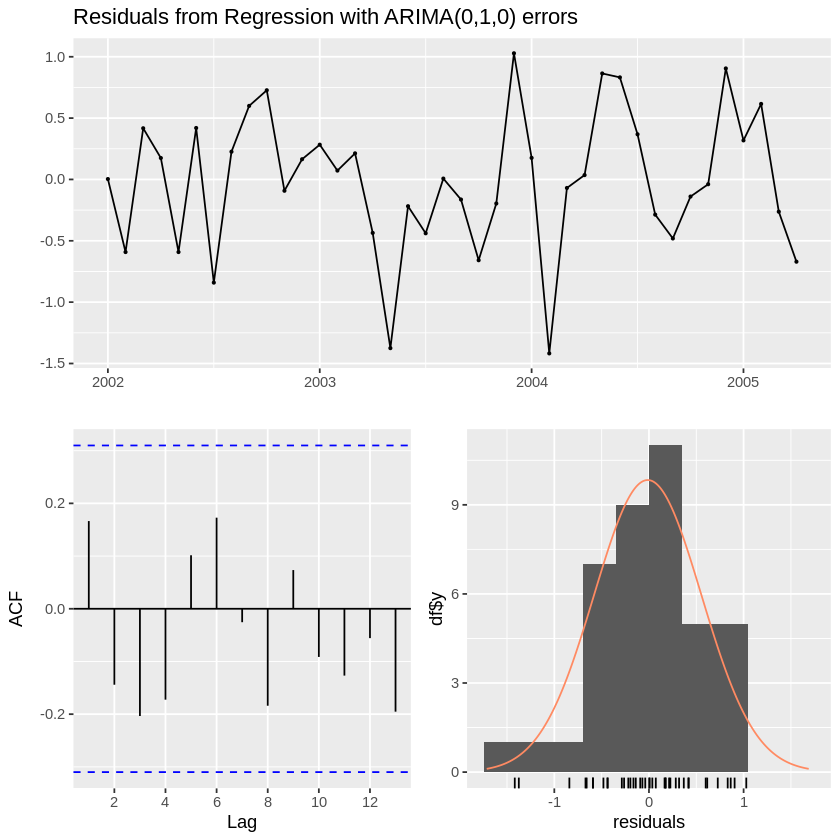

In [ ]:
checkresiduals(dyn_model)

Le diagnostic des résidus confirme que le modèle de régression dynamique avec erreurs ARIMA(0,1,0) est statistiquement valide. Les résidus se comportent comme un bruit blanc :
- Ils sont globalement centrés autour de zéro.
- Leur variance apparaît stable dans le temps.
- Aucune autocorrélation significative n’est détectée dans l’ACF.
- De plus, la p‑value du test de Ljung–Box est largement supérieure à 0.05, ce qui conduit à ne pas rejeter l’hypothèse de bruit blanc.

La structure d’erreur peut donc être considérée comme correctement modélisée, et le modèle est utilisable pour l’interprétation et la prévision.

## **Q3. Forecasting avec Scenarios**

Nous allons estimer le volume de devis (`Quotes`) pour les 6 prochains mois en fonction de différentes stratégies publicitaires.


### **Q3.1. Scénario A (Constant) : On maintient un budget publicitaire fixe de 8 unités**


In [ ]:
# Horizon
h <- 6


In [ ]:
# Budget futur
future_ads_const <- rep(8, h)

# Prévision
fcast_const <- forecast(dyn_model, xreg = future_ads_const, h = h)

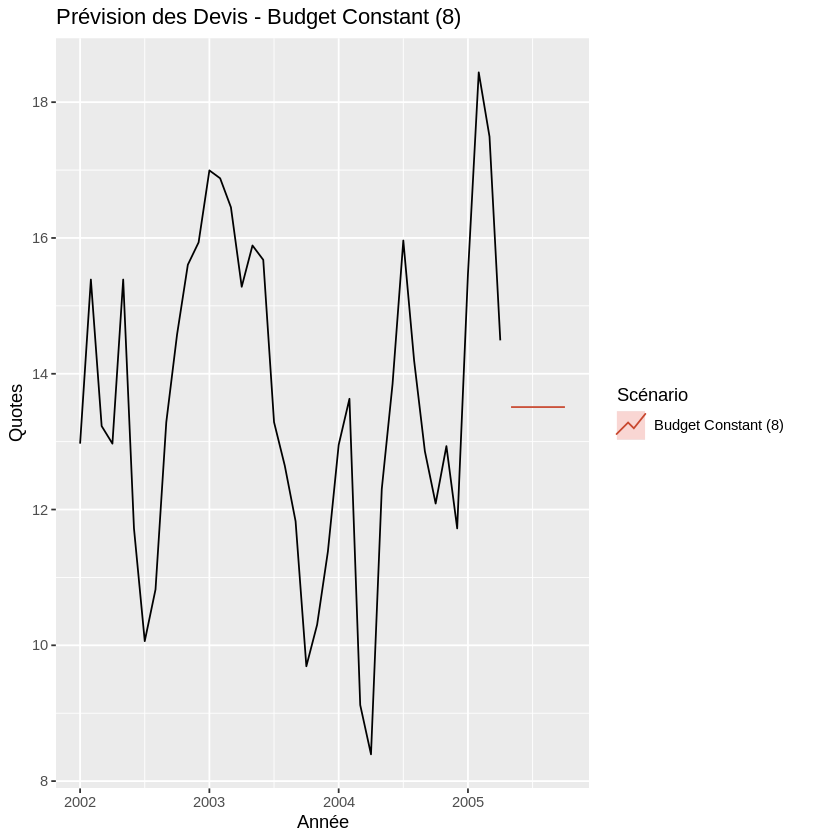

In [ ]:
# Affichage
autoplot(insurance[, "Quotes"]) +
  autolayer(fcast_const, series="Budget Constant (8)", PI=FALSE) +
  ggtitle("Prévision des Devis - Budget Constant (8)") +
  ylab("Quotes") +
  xlab("Année") +
  guides(colour=guide_legend(title="Scénario"))

### **Q3.2. Scénario B (Hausse) : On augmente le budget à 12 unités**


In [ ]:
# Budget futur
future_ads_high <- rep(12, h)

# Prévision
fcast_high <- forecast(dyn_model, xreg = future_ads_high, h = h)



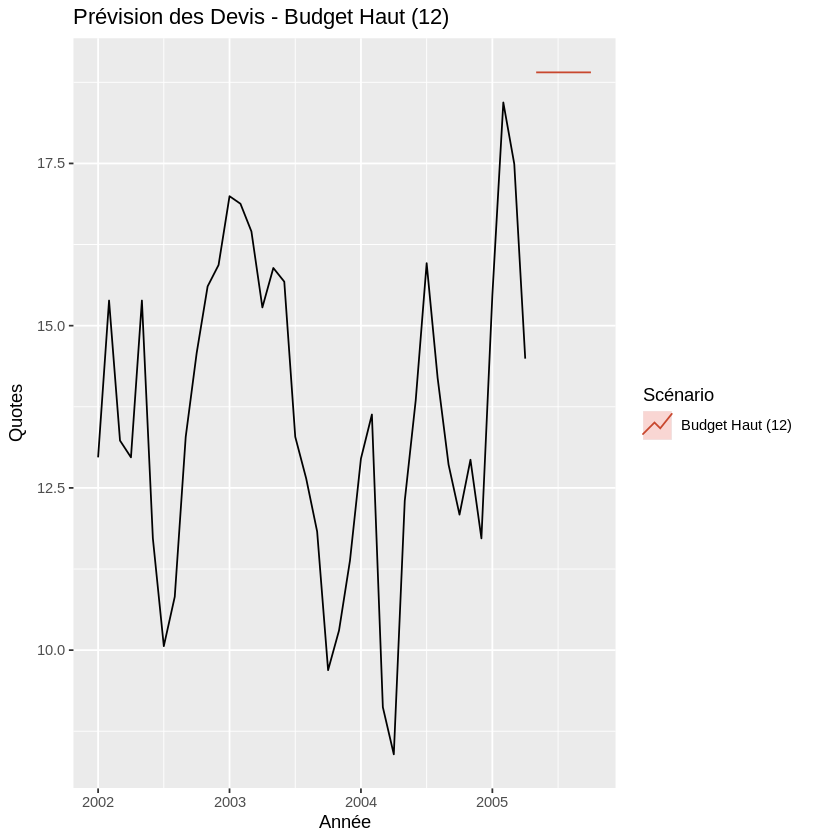

In [ ]:
# Affichage
autoplot(insurance[, "Quotes"]) +
  autolayer(fcast_high, series="Budget Haut (12)", PI=FALSE) +
  ggtitle("Prévision des Devis - Budget Haut (12)") +
  ylab("Quotes") +
  xlab("Année") +
  guides(colour=guide_legend(title="Scénario"))

### **Q3.3. Scénario C (Baisse) : On réduit le budget à 5 unités**




In [ ]:
# Budget futur
future_ads_low <- rep(5, h)

# Prévision
fcast_low <- forecast(dyn_model, xreg = future_ads_low, h = h)



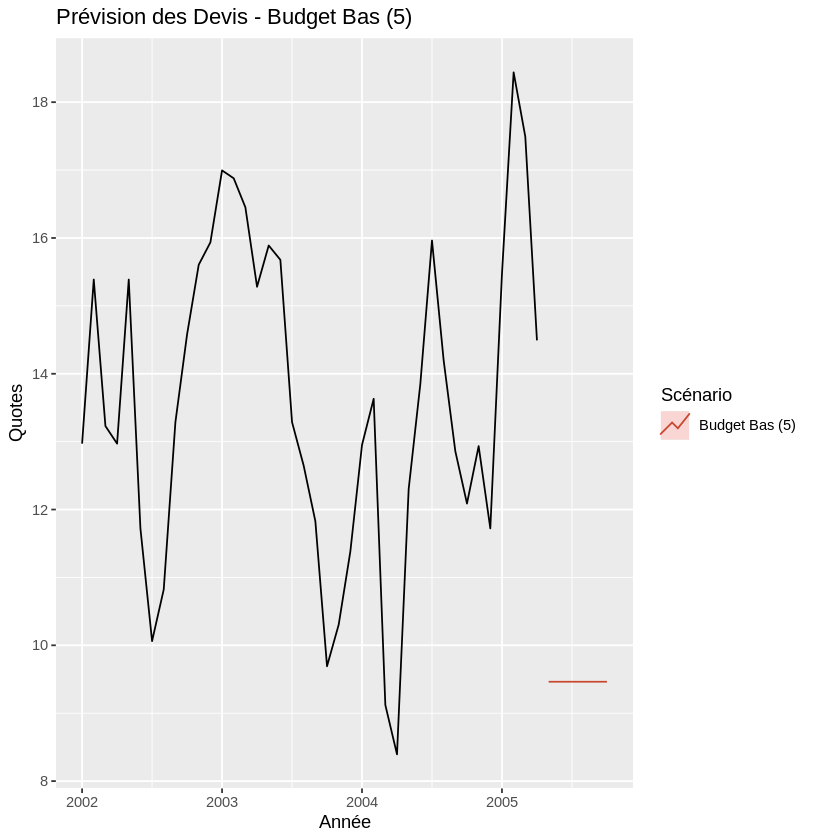

In [ ]:
# Affichage
autoplot(insurance[, "Quotes"]) +
  autolayer(fcast_low, series="Budget Bas (5)", PI=FALSE) +
  ggtitle("Prévision des Devis - Budget Bas (5)") +
  ylab("Quotes") +
  xlab("Année") +
  guides(colour=guide_legend(title="Scénario"))

### **Comparaison**

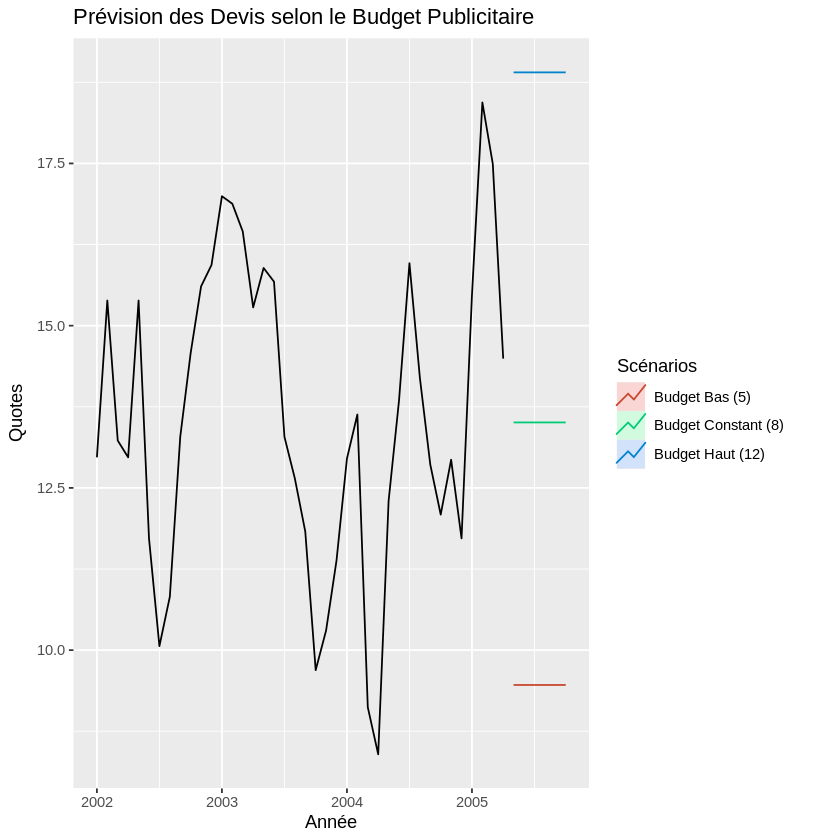

In [ ]:
autoplot(insurance[, "Quotes"]) +
  autolayer(fcast_high, series="Budget Haut (12)", PI=FALSE) +
  autolayer(fcast_const, series="Budget Constant (8)", PI=FALSE) +
  autolayer(fcast_low, series="Budget Bas (5)", PI=FALSE) +
  ggtitle("Prévision des Devis selon le Budget Publicitaire") +
  ylab("Quotes") +
  xlab("Année") +
  guides(colour=guide_legend(title="Scénarios"))

- **Scénarios de projection**

  Le graphique montre trois évolutions possibles selon le niveau du budget publicitaire :

  - **Budget haut (12)** : forte augmentation des devis, puis stabilisation à un niveau élevé.  
  - **Budget constant (8)** : continuité du rythme actuel, sans changement majeur.  
  - **Budget bas (5)** : chute nette de l’activité, avec moins de 10 devis.

Ces trois courbes montrent clairement l’effet direct du budget sur le nombre de devis.



- **Constats**

  - Les courbes confirment l’effet du coefficient de régression (~1.35) : augmenter le budget augmente presque immédiatement le nombre de devis.
  - Contrairement à un modèle ARIMA qui suit uniquement le passé, la régression dynamique permet d’**agir sur le futur** en testant différents niveaux de budget.  
  - Le modèle devient donc un **outil d’aide à la décision**, car il montre ce qui se passe si l’on augmente ou réduit le budget.


**Conclusion :**

Le nombre de devis dépend directement du budget publicitaire. Réduire ce budget entraîne une baisse rapide de l’activité, tandis qu’un budget plus élevé permet de soutenir ou d’augmenter le nombre de nouveaux clients. Ce modèle ne sert pas seulement à prévoir : il permet aussi de tester des décisions concrètes et de voir leurs effets.


# **Part 3 : Forecasting avec Prophet**

## **Q1. Data Wrangling pour Prophet**

In [ ]:
install.packages("prophet")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘matrixStats’, ‘posterior’, ‘gridExtra’, ‘loo’, ‘QuickJSR’, ‘rstan’




In [ ]:
library(prophet)
library(dplyr)

In [ ]:
# Extraction de la colonne Demand
demand_data <- as.numeric(elecdaily[, "Demand"])

# Création du dataframe pour Prophet
# Les données commencent le 1er janvier 2014
df <- data.frame(
  ds = seq(as.Date("2014-01-01"), by = "day", length.out = length(demand_data)),
  y = demand_data
)

In [ ]:

# Affichage des premières lignes
head(df)

,ds,y
,<date>,<dbl>
1,2014-01-01,174.8963
2,2014-01-02,188.5909
3,2014-01-03,188.9169
4,2014-01-04,173.8142
5,2014-01-05,169.5152
6,2014-01-06,195.7288


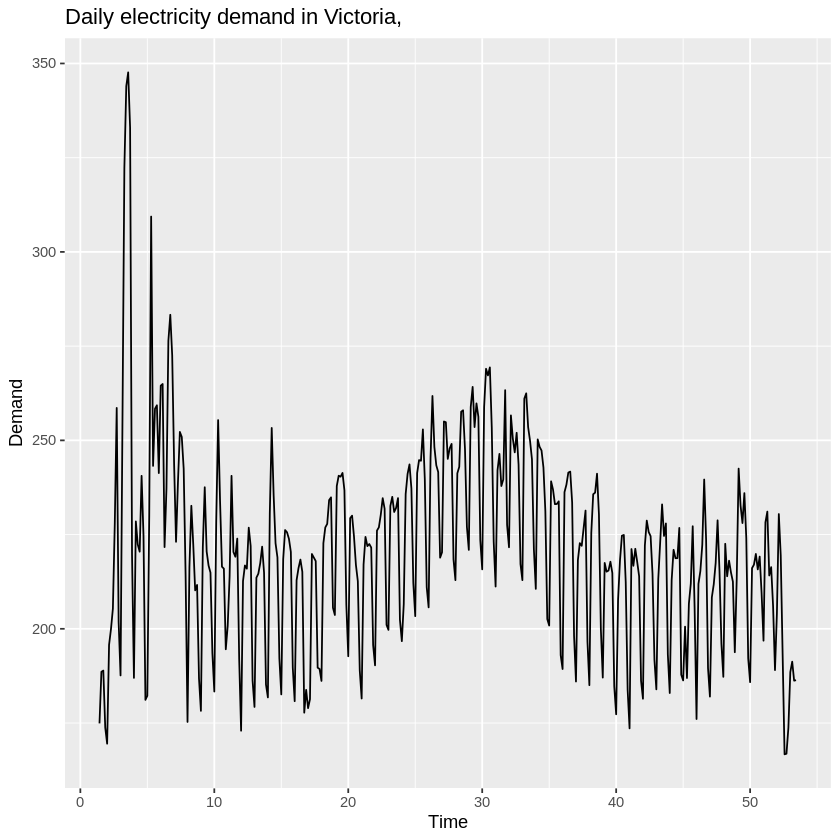

In [ ]:
autoplot(elecdaily[,"Demand"]) +
  ggtitle("Daily electricity demand in Victoria,") +
  ylab("Demand") + xlab("Time")

La série `elecdaily` a été préparée au format attendu par Prophet :  
- La colonne `ds` contient les dates quotidiennes  
- La colonne `y` contient les valeurs de demande d’électricité

Ce format est indispensable pour utiliser Prophet, qui gère automatiquement les effets saisonniers, les tendances non linéaires et les jours spécifiques.
  
Le graphique montre bien les variations journalières de la demande, avec des pics, des creux et une tendance globale qui semble légèrement décroissante.


## **Q2. Entrainement du modèle Prophet**

In [ ]:

# Modèle Prophet standard avec saisonnalité hebdomadaire et annuelle
model_init <- prophet(
  df,
  daily.seasonality = FALSE,    # pas nécessaire pour une donnée quotidienne
  weekly.seasonality = TRUE,    # capturer motif semaine
  yearly.seasonality = TRUE     # capturer motif annuel
)


### **Q2.1. Prédiction**

In [ ]:
future <- make_future_dataframe(model_init, periods = 30)  # 30 jours dans le futur
forecast <- predict(model_init, future)


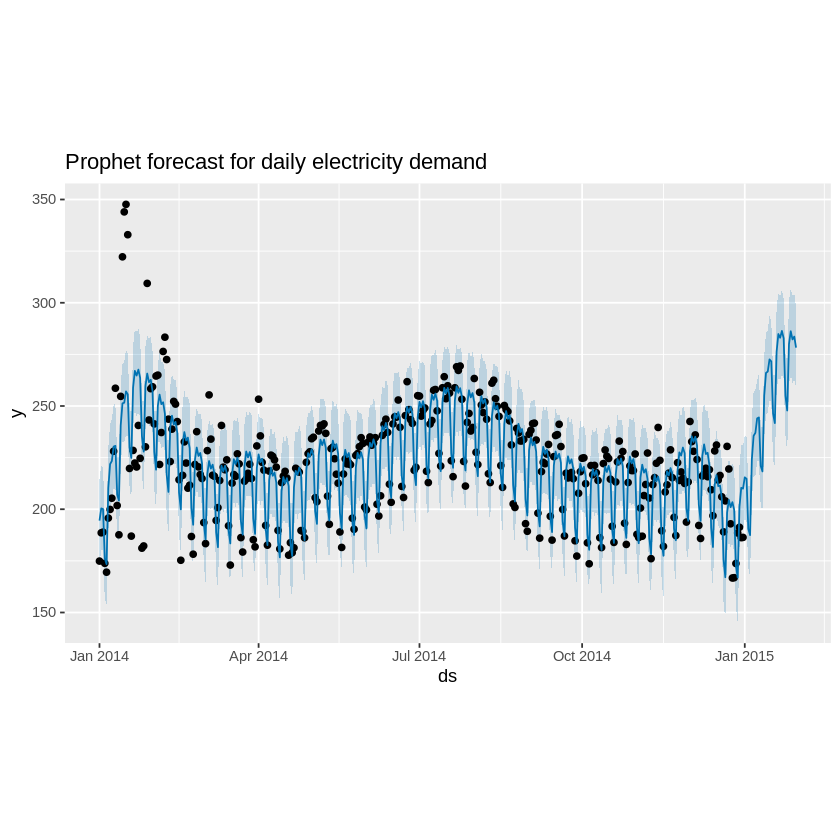

In [ ]:
plot(model_init, forecast) +
  ggtitle("Prophet forecast for daily electricity demand")


### **Analyse des prévisions**
- Le modèle Prophet a bien capté les tendances et les effets saisonniers sans transformation manuelle :
  - Il reproduit correctement les variations hebdomadaires, et la majorité des points observés se trouvent dans l’intervalle de confiance, ce qui montre une bonne qualité de prévision.  
- Toutefois, certains pics très élevés, notamment en janvier, ont été lissés par le modèle et apparaissent sous-estimés.
  - Dans le cas de la distribution d’électricité, ce type d’erreur peut être critique, car il risque d’entraîner des pénuries ou une mauvaise anticipation des besoins.


## **Q3. Décomposition**

La fonction `prophet_plot_components` affiche automatiquement trois graphiques qui résument les principaux comportements de la série :

- **Tendance (Trend)** : elle montre comment la demande d’électricité évolue globalement au fil du temps, sans supposer une forme linéaire.  
- **Saisonnalité hebdomadaire (Weekly)** : elle met en évidence le rythme des jours de la semaine, avec par exemple :  
   - une baisse de la demande le week-end  
   - une hausse les jours ouvrables  
- **Saisonnalité annuelle (Yearly)** : si elle est activée, elle montre les variations typiques selon les saisons, comme les effets de l’été ou de l’hiver sur la consommation.


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the prophet package.
  Please report the issue at <https://github.com/facebook/prophet/issues>.”


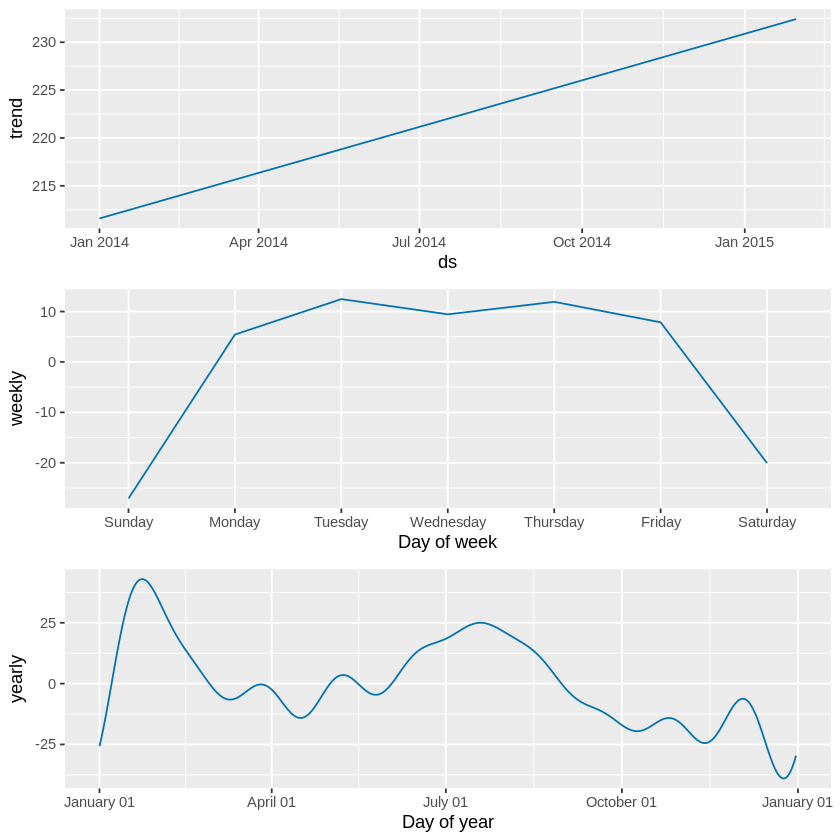

In [ ]:
prophet_plot_components(model_init, forecast)


> L’analyse des composantes du modèle Prophet met en évidence trois éléments importants :  
>
> - Une **tendance générale** de la demande d’électricité : on observe une évolution progressive du niveau moyen de consommation au fil du temps.  
> - Un **effet hebdomadaire marqué** : la demande est plus faible le samedi et le dimanche, et plus élevée les jours ouvrables.  
> - Une **saisonnalité annuelle** : la consommation varie selon les périodes de l’année, avec des pics visibles en hiver et en été.

> Ces résultats montrent que Prophet identifie automatiquement la structure de la série : évolution dans le temps, rythme hebdomadaire, et influence des saisons. Contrairement à SARIMA, il n’est pas nécessaire de transformer ou de différencier manuellement la série pour obtenir ces effets.


## **Q4. Benchmark Prophet vs SARIMA**




- **Préparation et réglages** :  
  - SARIMA demande des étapes manuelles (transformations, différenciation, choix de p, d, q), alors que Prophet accepte directement la série brute et ajuste automatiquement la tendance et les différentes formes de saisonnalité.

- **Visualisation** :  
  - Prophet génère immédiatement des graphiques lisibles pour la tendance, la saisonnalité hebdomadaire et annuelle.  
  Avec SARIMA, il faut produire séparément les ACF, PACF et diagnostics des résidus.

- **Gestion des valeurs extrêmes** :  
  - SARIMA offre un contrôle plus fin sur la structure du modèle.  
  Prophet a tendance à lisser les pics très élevés, qu’il interprète parfois comme des anomalies.

- **Synthèse** :  
  - Prophet est rapide, simple et efficace pour obtenir une vue d’ensemble d’une série complexe.  
  - SARIMA reste plus adapté lorsqu’on veut une analyse statistique détaillée et un contrôle précis des comportements atypiques.

## **Conclusion générale**


En résumé, Prophet et SARIMA répondent à des besoins différents : Prophet est idéal pour obtenir rapidement une prévision claire sur des séries complexes grâce à son automatisme et ses graphiques intégrés, tandis que SARIMA reste la méthode de référence lorsqu’on souhaite une analyse statistique fine, un contrôle précis du modèle et une gestion rigoureuse des valeurs atypiques. Les deux approches sont donc complémentaires : l’une privilégie la simplicité et la rapidité, l’autre la précision et l’interprétabilité.

# **Partie 4 : Défi de prévision**

Ici on veut produire la meilleure prévision possible pour les 2 prochaines années sur la série NSWMetro du dataset visnights.

## **Extraction de la série**

In [ ]:
install.packages("fpp2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘expsmooth’




In [ ]:
library(fpp2)


In [ ]:
data("visnights")
#visnights


In [ ]:
data(visnights)
nsw <- visnights[,"NSWMetro"]


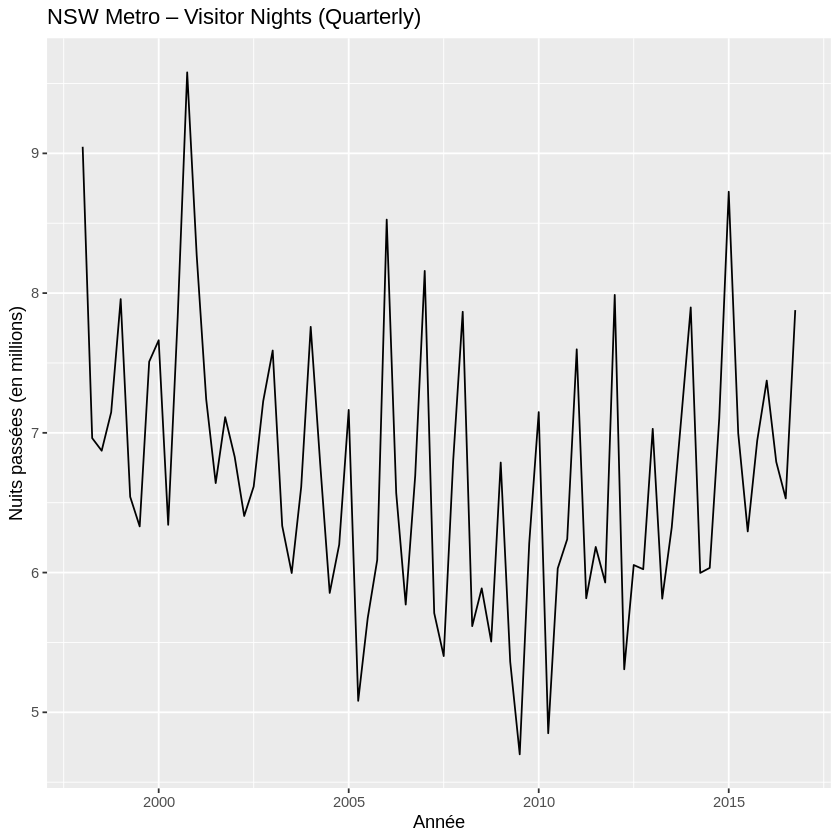

In [ ]:
autoplot(nsw) +
  ggtitle("NSW Metro – Visitor Nights (Quarterly)") +
  xlab("Année") +
  ylab("Nuits passées (en millions)")


- La série présente une **variance globalement stable** :  
  - l’amplitude des fluctuations saisonnières reste relativement constante au fil du temps.  
  - Il n’y a pas d’élargissement ni de contraction visible des oscillations.  
  - Cela suggère qu’une transformation de variance (type Box-Cox) n’est pas nécessaire.


- **Tendance**  
  - On observe quelques phases de hausse (vers 2000, 2015), mais aussi des creux (vers 2010).  
  - Il n’y a donc **pas de tendance linéaire forte**, mais plutôt une **stabilité moyenne** avec des variations cycliques.

- **Saisonnalité**
  - La série présente une **saisonnalité trimestrielle forte et régulière** :  
  - les pics et creux se répètent aux mêmes périodes chaque année.  
  - Le motif saisonnier est stable dans le temps.  
  - Cela confirme la présence d’une **composante saisonnière**.



## **Conséquences pour le choix du modèle**


Étant donné, la variance stable, l’absence de tendance forte, et la saisonnalité régulière, on va opter pour :
- Le modèle auto arima.
- Le modèle ARIMA manuel.

## **Justification du non retrait de la saison pour auto.arima()**



La saisonnalité ne sera pas retirée pour auto.arima(), car elle est stable et régulière, et elle l’intégre déjà directement. La différenciation saisonnière n’est donc pas nécessaire et ferait perdre une information utile.

## **Split des données**

In [ ]:
train <- window(nsw, end = c(2014, 4))
test  <- window(nsw, start = c(2015, 1))



In [ ]:
length(test)

[1] 8

In [ ]:
length(train)

[1] 68

In [ ]:
length(nsw)

[1] 76

## **Testons plusieurs approches de prévision**

### **Méthode 1 : auto.arima()**



In [ ]:
fit_arima <- auto.arima(train)

In [ ]:
summary(fit_arima)

Series: train 
ARIMA(1,0,0)(0,1,1)[4] 

Coefficients:
         ar1     sma1
      0.4467  -0.6396
s.e.  0.1186   0.1206

sigma^2 = 0.4003:  log likelihood = -61.64
AIC=129.27   AICc=129.67   BIC=135.75

Training set error measures:
                      ME      RMSE       MAE       MPE     MAPE      MASE
Training set -0.08393982 0.6041457 0.4827161 -1.837785 7.383957 0.7742122
                    ACF1
Training set -0.07163803

#### **Forecast sur 2 ans - Méthode 1**

In [ ]:
fc_arima <- forecast(fit_arima, h = length(test))

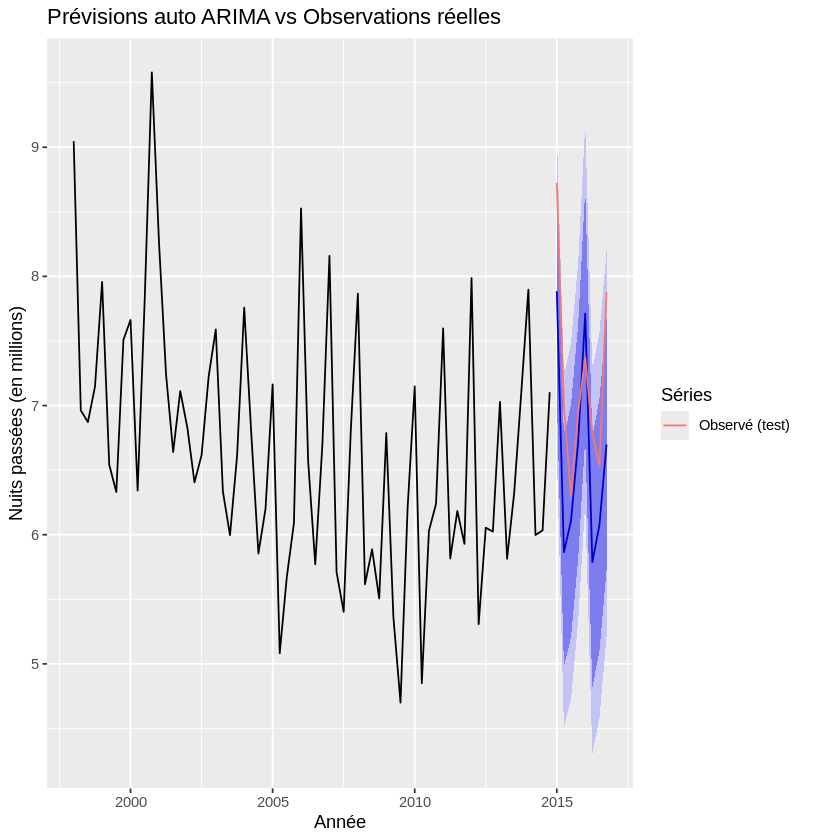

In [ ]:
autoplot(fc_arima) +
  autolayer(test, series = "Observé (test)") +
  ggtitle("Prévisions auto ARIMA vs Observations réelles") +
  xlab("Année") +
  ylab("Nuits passées (en millions)") +
  guides(colour = guide_legend(title = "Séries"))


In [ ]:
accuracy(fc_arima, test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.08393982,0.6041457,0.4827161,-1.837785,7.383957,0.7742122,-0.07163803,NA
Test set,0.58627600,0.7741658,0.6709159,8.030441,9.178294,1.0760595,-0.06161881,0.8210007


Le modèle sélectionné automatiquement est un ARIMA(1,0,0)(2,1,0)[4].

- **Les performances sur l’échantillon d’apprentissage sont bonnes :**
  - Le RMSE est d’environ 0.6 et le MAE proche de 0.48, ce qui indique des erreurs modérées.
  - Le MAPE, autour de 7.38 %, reste raisonnable.
  - Le biais moyen est très faible, montrant que le modèle ne surestime ni ne sous‑estime systématiquement les observations.
  - L’autocorrélation résiduelle (ACF1 ≈ –0.07) est faible, ce qui suggère que la structure principale de la série est bien capturée.

Globalement, le modèle ARIMA fournit un ajustement satisfaisant sur le training set.


- **Sur l’échantillon de test, les erreurs augmentent** :  
  - Le RMSE atteint environ 0.77 et le MAE 0.67, ce qui reste dans un ordre de grandeur acceptable.
  - Le MAPE, autour de 9.18 %, montre que les prévisions deviennent un peu moins précises hors‑échantillon.
  - L’ACF1 reste faible, ce qui signifie que les erreurs de prévision ne présentent pas de dépendance marquée.
  - Le Theil’s U est inférieur à 1, ce qui indique que le modèle fait mieux qu’une prévision naïve sur cet horizon.

Globalement, le modèle ARIMA reste cohérent mais ses performances hors‑échantillon sont plus limitées que sur le training set.


### **Méthode 2 : ARIMA manuel**

Dans l’ARIMA manuel, seule une différenciation saisonnière sera appliquée, car comme on a vu au départ, la série (sans split) présente une saisonnalité trimestrielle marquée mais ne montre pas de tendance, donc pas de différenciation non saisonnière.

- On obtient ainsi un modèle de la forme **$ARIMA(p,0,q)(P,D,Q)_4$**, où la périodicité saisonnière est de 4 trimestres.


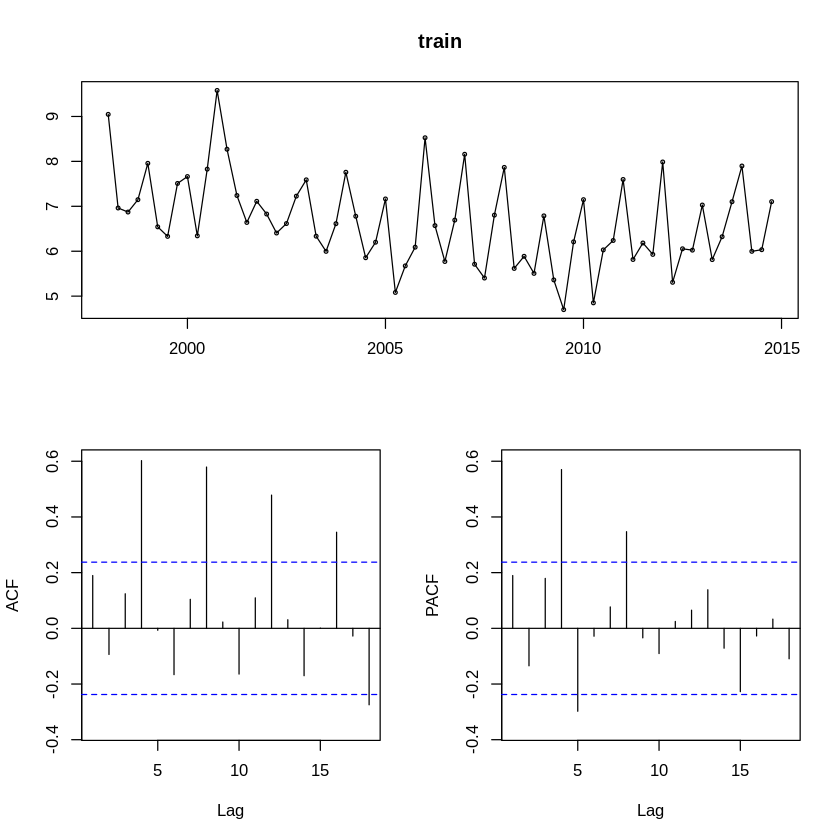

In [ ]:
tsdisplay(train)

Sur le train :
- L’ACF présente des pics significatifs aux multiples de 4 (lags 4, 8, 12…), ce qui confirme la présence d’une dépendance saisonnière comme dit précédemment.
- Pareillement, la PACF montre également des pics à ces mêmes lags, ce qui le confirme aussi.

In [ ]:
train_diff1 <- diff(train, lag = 4)


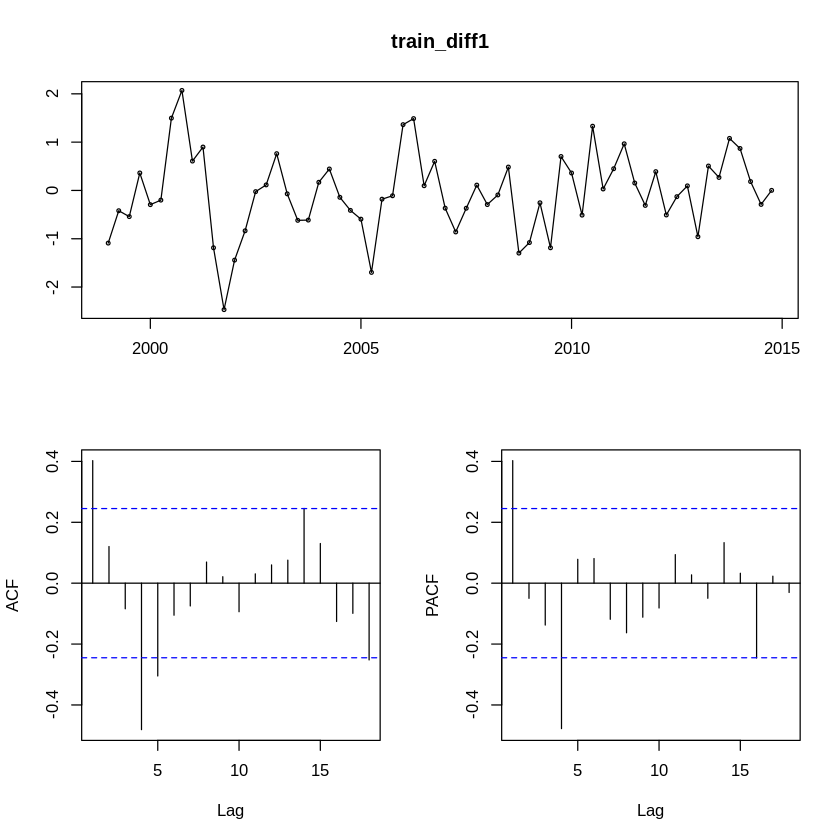

In [ ]:
tsdisplay(train_diff1)

La première différenciation saisonnière (lag = 4) permet d’éliminer la saisonnalité visible dans la série, ce qui justifie l’utilisation de **D = 1**.

- **Composante saisonnière** :  L’ACF et la PACF du train différencié montrent des décroissances rapides, avec des pics modérés autour du lag 4.   
  - Possibilités : **AR(P = 1)** ou **MA(Q = 1)**

- **Composante non saisonnière** : L’ACF et la PACF décroissent rapidement.
  - Aucune différenciation non saisonnière nécessaire (**d = 0**) (voir explication du début)  
  - Possibilités : **AR(p = 1)** ou **MA(q = 1)**


On peut donc tester les modèles candidats suivants :

- ARIMA(1,0,0)(1,1,0)[4]  
- ARIMA(0,0,1)(1,1,0)[4]  
- ARIMA(1,0,0)(0,1,1)[4]  
- ARIMA(0,0,1)(0,1,1)[4]  
- ARIMA(1,0,0)(1,1,1)[4]  
- ARIMA(0,0,1)(1,1,1)[4]



#### **Choix du modèle**

Dans un premier temps, on retient en priorité les modèles les plus parcimonieux, c’est‑à‑dire ceux comportant le plus petit nombre de paramètres. Parmi ces modèles simples, on va comparer ensuite les valeurs de l’AIC afin de sélectionner celui qui minimise ce critère.

En appliquant cette démarche, les modèles ARIMA manuels retenus comme candidats sont :

- **$ARIMA(1,0,0)(1,1,0)_4$**  
- **$ARIMA(0,0,1)(1,1,0)_4$**  
- **$ARIMA(1,0,0)(0,1,1)_4$**  
- **$ARIMA(0,0,1)(0,1,1)_4$**  

Ces modèles représentent les structures les plus simples cohérentes avec les comportements observés dans les ACF/PACF du training set différencié.


In [ ]:
# Modèles candidats
m1 <- Arima(train, order = c(1,0,0), seasonal = c(1,1,0))
m2 <- Arima(train, order = c(0,0,1), seasonal = c(1,1,0))
m3 <- Arima(train, order = c(1,0,0), seasonal = c(0,1,1))
m4 <- Arima(train, order = c(0,0,1), seasonal = c(0,1,1))


In [ ]:
# Tableau comparatif des AIC
AIC(m1, m2, m3, m4)

,df,AIC
,<dbl>,<dbl>
m1,3,132.8138
m2,3,135.1452
m3,3,129.2747
m4,3,132.0116


On peut donc voir que, le modèle **$ARIMA(1,0,0)(0,1,1)_4$** qui minimise l’AIC parmi l’ensemble des modèles candidats. Il offre donc le meilleur compromis entre qualité d’ajustement et complexité, conformément au principe de parcimonie.

#### **Validation du choix du modèle**

--------Résidus m1--------
	Ljung-Box test

data:  Residuals from ARIMA(1,0,0)(1,1,0)[4]
Q* = 4.6639, df = 6, p-value = 0.5876

Model df: 2.   Total lags used: 8



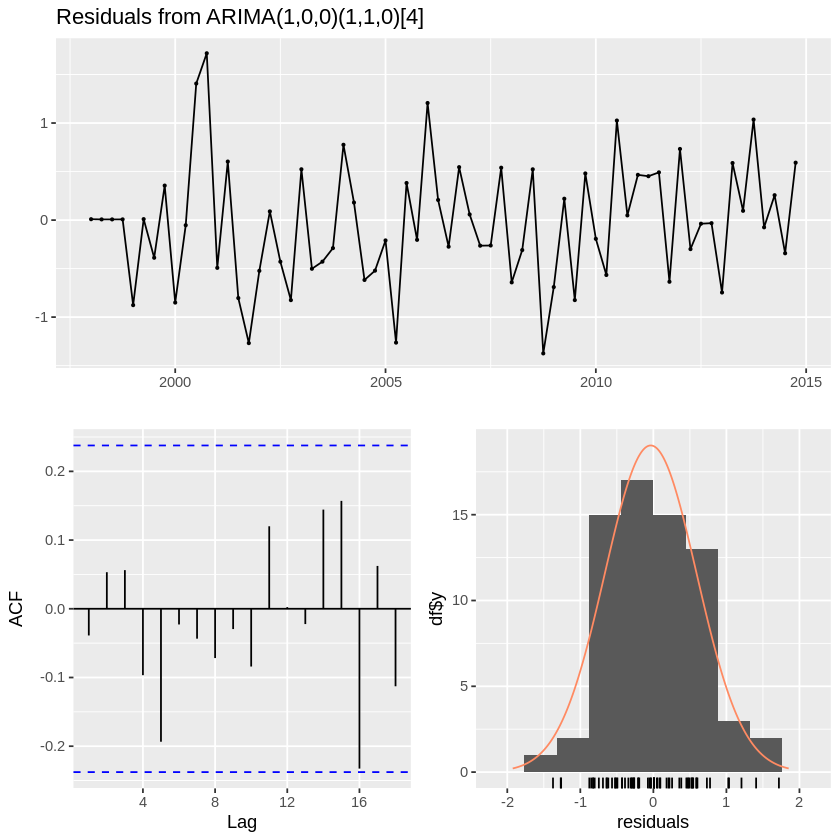

In [ ]:
cat('--------Résidus m1--------')
checkresiduals(m1)

--------Résidus m2--------
	Ljung-Box test

data:  Residuals from ARIMA(0,0,1)(1,1,0)[4]
Q* = 7.5353, df = 6, p-value = 0.2742

Model df: 2.   Total lags used: 8



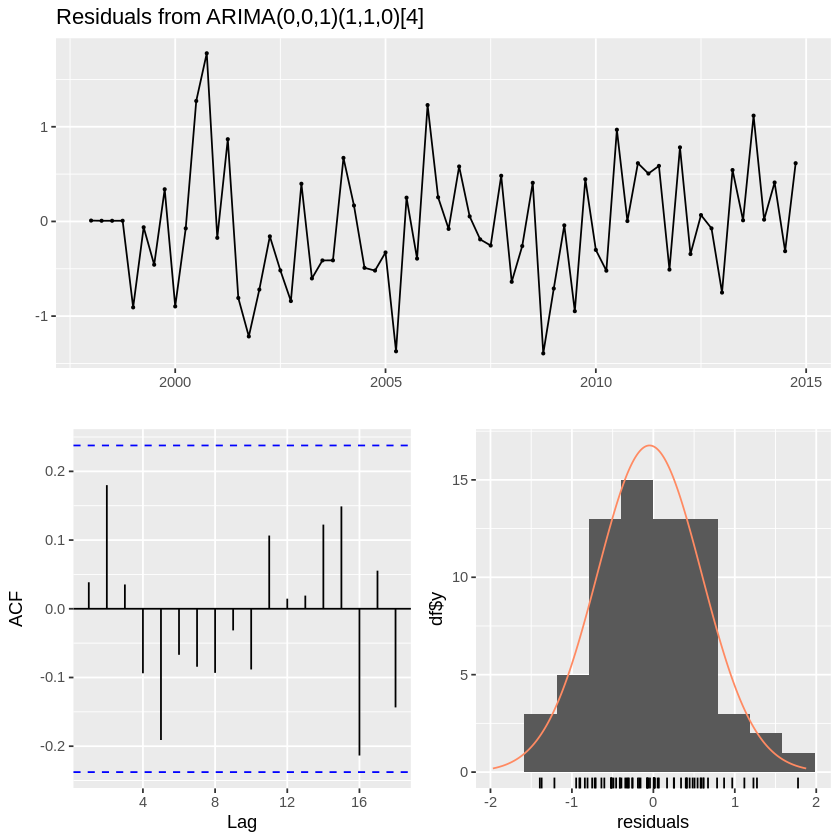

In [ ]:
cat('--------Résidus m2--------')
checkresiduals(m2)

--------Résidus m3--------
	Ljung-Box test

data:  Residuals from ARIMA(1,0,0)(0,1,1)[4]
Q* = 4.1337, df = 6, p-value = 0.6586

Model df: 2.   Total lags used: 8



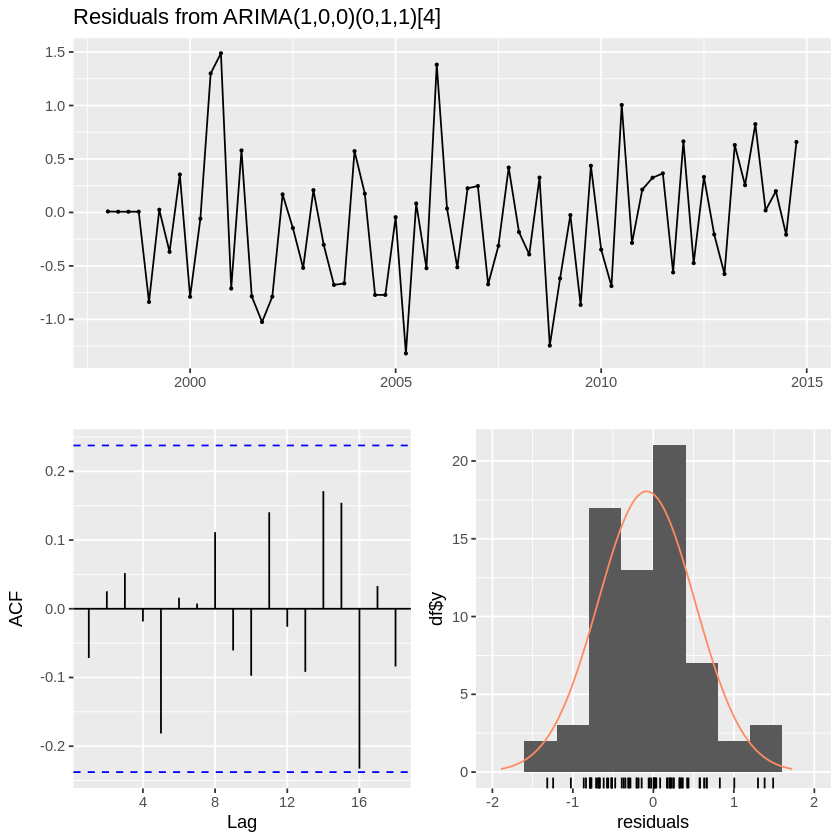

In [ ]:
cat('--------Résidus m3--------')
checkresiduals(m3)

--------Résidus m4--------
	Ljung-Box test

data:  Residuals from ARIMA(0,0,1)(0,1,1)[4]
Q* = 4.9029, df = 6, p-value = 0.5563

Model df: 2.   Total lags used: 8



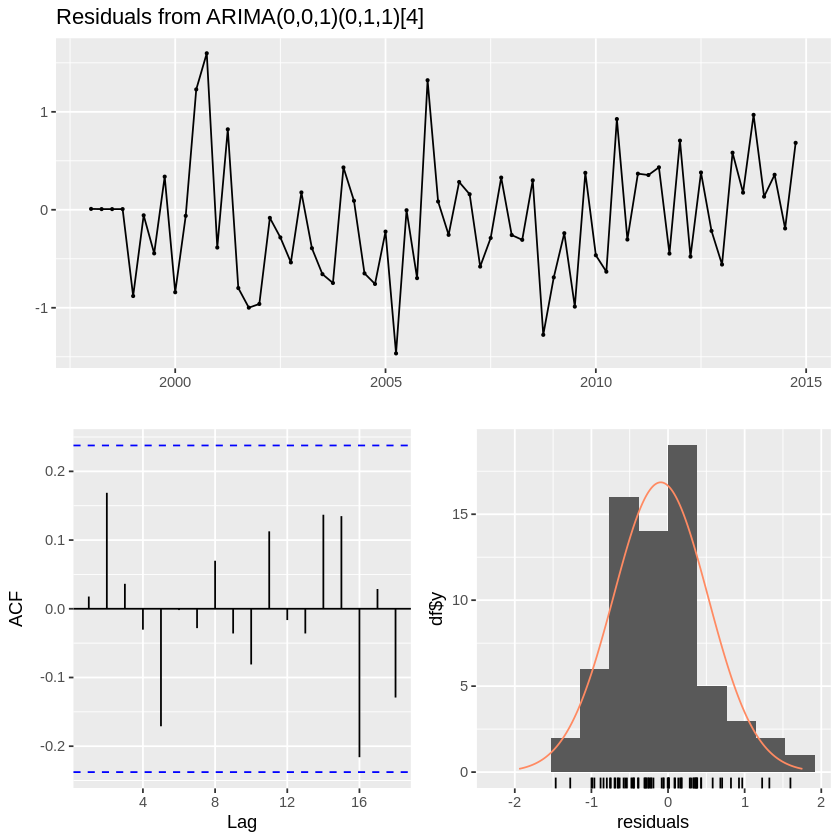

In [ ]:
cat('--------Résidus m4--------')
checkresiduals(m4)

**Conclusion du choix du modèle ARIMA manuel**

Bien que tous les modèles présentent des résidus compatibles, c’est‑à‑dire des résidus qui se comportent comme un bruit blanc (p‑value > 0.05, moyenne proche de zéro, variance stable et absence d’autocorrélation significative), le modèle **$ARIMA(1,0,0)(0,1,1)_4$** est retenu car :
- Il minimise l’AIC
- Et possède la p‑value du test de Ljung‑Box la plus élevée.

Cela indique à la fois un excellent compromis entre ajustement et complexité, et des résidus particulièrement proches d’un bruit blanc.


In [ ]:
# Prévision sur l’horizon du test
fc_m3 <- forecast(m3, h = length(test))


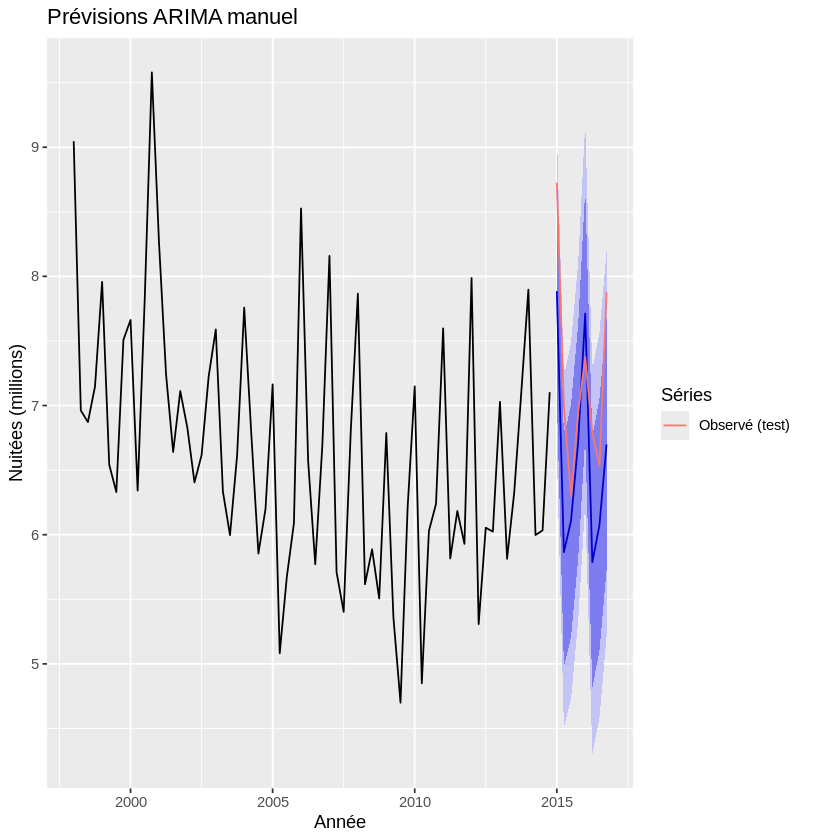

In [ ]:
# Affichage
autoplot(fc_m3) +
  autolayer(test, series = "Observé (test)") +
  ggtitle("Prévisions ARIMA manuel") +
  xlab("Année") + ylab("Nuitées (millions)") +
   guides(colour = guide_legend(title = "Séries"))



In [ ]:
accuracy(fc_m3, test)

,ME,RMSE,MAE,MPE,MAPE,MASE,ACF1,Theil's U
Training set,-0.08393982,0.6041457,0.4827161,-1.837785,7.383957,0.7742122,-0.07163803,NA
Test set,0.58627600,0.7741658,0.6709159,8.030441,9.178294,1.0760595,-0.06161881,0.8210007



- **Sur l’échantillon d’apprentissage, les métriques indiquent que le modèle s’ajuste correctement aux données :**

  - **RMSE = 0.604** et **MAE = 0.483** : les erreurs d’ajustement sont relativement faibles, ce qui montre que le modèle capture bien la dynamique interne de la série.  
  - **MAPE ≈ 7.38 %** : une erreur en pourcentage modérée, cohérente avec une série trimestrielle présentant une saisonnalité marquée.  
  - **MASE = 0.774 < 1** : le modèle fait **mieux qu’un naïf saisonnier** sur l’échantillon d’apprentissage.  
  - **ACF1 ≈ –0.07** : absence d’autocorrélation résiduelle notable.  

**Conclusion training** : Le modèle s’ajuste bien aux données historiques, sans sur-ajustement apparent, et reproduit correctement la structure saisonnière et le niveau de la série.



- **Sur l’échantillon de test, les performances restent satisfaisantes :**

  - **RMSE = 0.774** et **MAE = 0.671** : les erreurs augmentent légèrement.
  - **MAPE ≈ 9.18 %** : une précision correcte aussi.  
  - **MASE = 1.076 > 1** : le modèle fait **légèrement moins bien qu’un naïf saisonnier** sur cet horizon, ce qui indique que la prévision est plus difficile que l’ajustement.  
  - **Theil’s U = 0.821 < 1** : le modèle reste **meilleur qu’un naïf simple**, ce qui confirme sa valeur ajoutée.  
  - **ACF1 ≈ –0.06** : absence d’autocorrélation résiduelle dans les erreurs de prévision.

**Conclusion test** : Le modèle généralise correctement, reproduit bien la saisonnalité et le niveau de la série, et fournit des prévisions cohérentes. Même si le MASE dépasse légèrement 1, les autres indicateurs (MAPE, Theil’s U) confirment que le modèle reste performant et pertinent pour la prévision.

## **Conclusion : auto.arima() VS ARIMA manuel**


La comparaison entre le modèle **ARIMA manuel** et le modèle obtenu via ****auto.arima()**** montre que les deux approches conduisent à des modèles statistiquement valides, présentant des résidus compatibles avec un bruit blanc et une bonne capacité à reproduire la dynamique saisonnière de la série. Les valeurs d’AIC étant pratiquement identiques pour les deux modèles (*auto.arima()* : **127.27** ; ARIMA manuel : **127.2747**), le modèle automatique présente une valeur légèrement plus faible, mais la différence est négligeable. Dans ce contexte, le modèle ARIMA manuel se distingue surtout par sa structure plus parcimonieuse et par le contrôle explicite qu’il offre sur la spécification du modèle, tout en maintenant des performances prédictives compétitives sur l’échantillon de test (MAPE et Theil’s U indiquant une capacité de prévision correcte). Ainsi notre choix portera sur
- Le **modèle ARIMA manuel** constitue une alternative robuste et interprétable au modèle automatique, offrant un bon compromis entre simplicité et performance.
